# Imports, Constants, and Shared Setup

In [58]:
from pathlib import Path
import argparse
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import ee
import geemap
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
from dotenv import load_dotenv

%matplotlib inline
from matplotlib.colors import ListedColormap
from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "samples_generated"
if not DATA_DIR.exists():
    DATA_DIR = ROOT / "data" / "samples_prepared"

MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {1: "Greenery", 2: "Sand", 3: "Water", 4: "Cement"}
CLASS_IDS = list(CLASS_NAMES)
TARGET_NAMES = [CLASS_NAMES[class_id] for class_id in CLASS_IDS]

COLORS = np.array([
    [0, 0, 0],
    [0, 100, 0],
    [184, 134, 11],
    [0, 0, 139],
    [105, 105, 105],
], dtype=np.uint8)

RANDOM_STATE = 42
TARGET_SAMPLE = "AlKhargaOasis"

def clean_mask(mask, edge_size=3):
    clean = mask.copy()
    noisy_edge = maximum_filter(clean, size=edge_size) != minimum_filter(clean, size=edge_size)
    clean[(~np.isin(clean, CLASS_IDS)) | noisy_edge] = 0
    return clean

def scale_input(spectral):
    return np.clip(spectral / 10000.0, 0, 1)

def rgb_preview(spectral):
    rgb = np.moveaxis(spectral[[3, 2, 1]], 0, -1)
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - low) / (high - low + 1e-6), 0, 1)

def colorize(mask):
    return COLORS[mask]

records = []
for spectral_path in sorted(DATA_DIR.glob("*/*_Spectral.tif")):
    sample = spectral_path.parent.name
    mask_path = spectral_path.with_name(f"{sample}_Mask.tif")
    if mask_path.exists():
        records.append({
            "sample": sample,
            "spectral_path": spectral_path,
            "mask_path": mask_path,
        })

samples = pd.DataFrame.from_records(records)
if samples.empty:
    raise FileNotFoundError(f"No paired spectral/mask files found in {DATA_DIR}")


# Data Acquisition

In [59]:
# Data Acquisition Settings
DEFAULT_CSV = ROOT / "locations.csv"
OUT_DIR = ROOT / "data" / "samples_generated"

START_DATE = "2025-05-01"
END_DATE = "2025-08-28"
BUFFER_M = 1280
MAX_CLOUD = 20
SCALE = 10
MIN_LABEL_CONFIDENCE = 0.45

S2_BANDS = [
    "B1", "B2", "B3", "B4", "B5", "B6",
    "B7", "B8", "B8A", "B9", "B11", "B12",
]

CLASS_PROB_BANDS = {
    "greenery": ["trees", "grass", "flooded_vegetation", "crops"],
    "sand": ["bare"],
    "water": ["water"],
    "cement": ["built"],
}

DW_PROB_BANDS = [band for bands in CLASS_PROB_BANDS.values() for band in bands]

NAME_ALIASES = {
    "Cairo University": "CairoUniv",
    "Iconic Tower, New Administrative Capital": "IconicTower",
}

def sample_name(name):
    if name in NAME_ALIASES:
        return NAME_ALIASES[name]
    words = "".join(c if c.isalnum() else " " for c in name).split()
    return "".join(word[:1].upper() + word[1:] for word in words)

def init_ee():
    load_dotenv()
    project = os.getenv("EE_PROJECT_ID") or os.getenv("EE_PROJECT")
    try:
        ee.Initialize(project=project) if project else ee.Initialize()
    except Exception as e:
        print("Earth Engine is not ready. Run `earthengine authenticate` first.")

def mask_clouds(image):
    scl = image.select("SCL")
    clear = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(clear)

def sentinel2(region, start, end, max_cloud):
    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(region)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", max_cloud))
        .map(mask_clouds)
    )

def dynamic_world(region, start, end):
    return ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1").filterBounds(region).filterDate(start, end)

def confident_mask(dw, region):
    probs = dw.select(DW_PROB_BANDS).mean().clip(region)
    scores = ee.Image.cat(*[
        probs.select(bands).reduce(ee.Reducer.sum()).rename(name)
        for name, bands in CLASS_PROB_BANDS.items()
    ])

    best_score = scores.reduce(ee.Reducer.max())
    mask = scores.toArray().arrayArgmax().arrayGet([0]).add(1).rename("macro_class")
    return mask.where(best_score.lt(MIN_LABEL_CONFIDENCE), 0).toUint8()

def build_image(region, start, end, max_cloud):
    s2 = sentinel2(region, start, end, max_cloud)
    dw = dynamic_world(region, start, end)
    spectral = s2.select(S2_BANDS).median().clip(region)
    image = spectral.addBands(confident_mask(dw, region))
    return image, s2.size().getInfo(), dw.size().getInfo()

def export_image(image, path, region):
    geemap.ee_export_image(
        image,
        str(path),
        crs="EPSG:4326",
        region=region,
        scale=SCALE,
        file_per_band=False,
        verbose=False,
    )
    if not path.exists():
        raise RuntimeError(f"export failed: {path.name} was not created")

def split_stack(stack_path, spectral_path, mask_path):
    with rio.open(stack_path) as src:
        data = src.read()
        profile = src.profile

    if data.shape[0] != len(S2_BANDS) + 1:
        raise RuntimeError(f"expected {len(S2_BANDS) + 1} bands, found {data.shape[0]}")

    spectral_profile = {**profile, "count": len(S2_BANDS), "dtype": "float64", "nodata": None}
    mask_profile = {**profile, "count": 1, "dtype": "uint8", "nodata": 0}

    with rio.open(spectral_path, "w", **spectral_profile) as dst:
        dst.write(data[:len(S2_BANDS)].astype("float64"))

    with rio.open(mask_path, "w", **mask_profile) as dst:
        dst.write(data[len(S2_BANDS):].astype("uint8"))

    stack_path.unlink(missing_ok=True)

def save_preview(spectral_path, mask_path, preview_path):
    with rio.open(spectral_path) as src:
        rgb = np.moveaxis(src.read([4, 3, 2]).astype("float32"), 0, -1)
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    rgb = np.clip((rgb - low) / (high - low + 1e-6), 0, 1)

    with rio.open(mask_path) as src:
        mask = src.read(1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[1].imshow(mask, cmap=ListedColormap(COLORS/255.0), vmin=0, vmax=4, interpolation="nearest")
    axes[1].set_title("Mask")

    for ax in axes:
        ax.axis("off")

    fig.tight_layout()
    fig.savefig(preview_path, dpi=122, facecolor="white")
    plt.close(fig)

def download_location(row, start, end, buffer_m, max_cloud):
    name = sample_name(row.name)
    folder = OUT_DIR / name
    folder.mkdir(parents=True, exist_ok=True)

    spectral_path = folder / f"{name}_Spectral.tif"
    mask_path = folder / f"{name}_Mask.tif"
    preview_path = folder / f"{name}_viz.png"
    stack_path = folder / f".{name}_stack.tif"

    point = ee.Geometry.Point([row.longitude, row.latitude])
    region = point.buffer(buffer_m).bounds()
    image, s2_count, dw_count = build_image(region, start, end, max_cloud)

    if not s2_count:
        print(f"skip {name}: no Sentinel-2 images")
        return "no_s2"
    if not dw_count:
        print(f"skip {name}: no Dynamic World images")
        return "no_dw"

    export_image(image, stack_path, region)
    split_stack(stack_path, spectral_path, mask_path)
    save_preview(spectral_path, mask_path, preview_path)
    print(f"saved {name}")
    return "saved"

class Args:
    csv = DEFAULT_CSV
    start = START_DATE
    end = END_DATE
    buffer = BUFFER_M
    max_cloud = MAX_CLOUD
    only = None

def parse_args():
    return Args()


In [60]:
args = parse_args()
init_ee()

if args.csv.exists():
    rows = pd.read_csv(args.csv)
    if args.only:
        rows = rows[rows["name"].isin(args.only)]
    
    locations = list(rows.itertuples(index=False))
    iterator = locations if len(locations) == 1 else tqdm(locations, desc="Locations", unit="loc")
    stats = {"saved": 0, "no_s2": 0, "no_dw": 0}
    
    # for row in iterator:
    #     status = download_location(row, args.start, args.end, args.buffer, args.max_cloud)
    #     stats[status] += 1
    # print(stats)
else:
    print("locations.csv not found, skipping download.")


Locations:   0%|          | 0/43 [00:00<?, ?loc/s]

# Random Forest Baseline

In [61]:
MAX_PIXELS_PER_CLASS = 1500

RF_PARAMS = {
    "n_estimators": 120,
    "max_depth": 24,
    "min_samples_leaf": 2,
    "class_weight": "balanced_subsample",
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

def load_sample_rf(row):
    with rio.open(row.spectral_path) as src:
        spectral = scale_input(src.read().astype("float32"))
    with rio.open(row.mask_path) as src:
        mask = clean_mask(src.read(1).astype("uint8"))
    return spectral, mask

def norm_diff(a, b):
    return (a - b) / (a + b + 1e-6)

def local_stats(image, size=5):
    mean = uniform_filter(image, size=size, mode="nearest")
    sq_mean = uniform_filter(image * image, size=size, mode="nearest")
    std = np.sqrt(np.clip(sq_mean - mean * mean, 0, None))
    return mean, std

def add_features(spectral):
    bands = np.moveaxis(spectral, 0, -1)
    b2, b3, b4 = bands[..., 1], bands[..., 2], bands[..., 3]
    b8, b11 = bands[..., 7], bands[..., 10]

    ndvi = norm_diff(b8, b4)
    ndwi = norm_diff(b3, b8)
    mndwi = norm_diff(b3, b11)
    ndbi = norm_diff(b11, b8)
    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + 1e-6)

    features = [
        bands,
        ndvi[..., None],
        ndwi[..., None],
        mndwi[..., None],
        ndbi[..., None],
        bsi[..., None],
    ]

    for layer in [ndvi, mndwi, ndbi, b11]:
        mean, std = local_stats(layer)
        features.extend([mean[..., None], std[..., None]])

    return np.dstack(features).astype("float32")

def predict_scene_rf(model, spectral):
    features = add_features(spectral)
    height, width, feature_count = features.shape
    pred = model.predict(features.reshape(-1, feature_count))
    return pred.reshape(height, width).astype("uint8")

def build_training_set(frame, max_per_class_per_image=MAX_PIXELS_PER_CLASS):
    rng = np.random.default_rng(RANDOM_STATE)
    xs, ys = [], []

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample_rf(row)
        features = add_features(spectral)
        flat_features = features.reshape(-1, features.shape[-1])
        labels = mask.reshape(-1)

        for class_id in CLASS_IDS:
            class_pixels = np.flatnonzero(labels == class_id)
            if len(class_pixels) == 0:
                continue

            take = min(max_per_class_per_image, len(class_pixels))
            picked_pixels = rng.choice(class_pixels, size=take, replace=False)

            xs.append(flat_features[picked_pixels])
            ys.append(np.full(take, class_id, dtype=np.uint8))

    return np.vstack(xs), np.concatenate(ys)

def evaluate_model_rf(model, frame):
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)
    y_true, y_pred = [], []

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample_rf(row)
        pred = predict_scene_rf(model, spectral)
        valid = mask > 0

        cm += confusion_matrix(mask[valid], pred[valid], labels=CLASS_IDS)
        y_true.append(mask[valid].reshape(-1))
        y_pred.append(pred[valid].reshape(-1))

    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
    iou = intersection / np.maximum(union, 1)

    metrics = pd.DataFrame({
        "class_id": CLASS_IDS,
        "class_name": TARGET_NAMES,
        "IoU": iou,
        "support": cm.sum(axis=1),
    })

    report = classification_report(
        np.concatenate(y_true),
        np.concatenate(y_pred),
        labels=CLASS_IDS,
        target_names=TARGET_NAMES,
        zero_division=0,
    )

    return metrics, report


In [62]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(samples, groups=samples["sample"]))

train_df = samples.iloc[train_idx].reset_index(drop=True)
test_df = samples.iloc[test_idx].reset_index(drop=True)

print(f"train scenes: {len(train_df)}")
print(train_df["sample"].tolist())
print()
print(f"test scenes: {len(test_df)}")
print(test_df["sample"].tolist())


train scenes: 32
['6thOfOctoberCity', 'AbuSimbel', 'AinSokhna', 'AswanHighDam', 'BahariyaOasis', 'BeniSuef', 'CairoUniv', 'DakhlaOasis', 'EastPortSaidPort', 'Edfu', 'ElAlamein', 'ElGouna', 'Farafra', 'GreatPyramidOfGiza', 'HawaraFayoum', 'Hurghada', 'IconicTower', 'KarnakLuxor', 'KomOmbo', 'Mallawi', 'MarsaAlam', 'MarsaMatrouh', 'Minya', 'NagHammadi', 'NewAlamein', 'NewCairo', 'PhilaeAswan', 'RasMuhammadNationalPark', 'SharqElOwainat', 'SuezPort', 'WadiElNatrun', 'Zagazig']

test scenes: 11
['AlKhargaOasis', 'Alexandria', 'Asyut', 'BenbanSolarPark', 'Damietta', 'LakeBurullus', 'LakeManzala', 'Qena', 'RashidRosetta', 'SaintCatherine', 'SiwaOasis']


In [63]:
X_train, y_train = build_training_set(train_df)

print(f"training pixels: {len(y_train):,}")
print(f"feature count: {X_train.shape[1]}")

pd.Series(y_train).map(CLASS_NAMES).value_counts().rename_axis("class").to_frame("pixels")


training pixels: 120,891
feature count: 25


,pixels
class,
Sand,41117
Cement,28573
Greenery,26785
Water,24416


In [64]:
model = RandomForestClassifier(**RF_PARAMS)
model.fit(X_train, y_train)
joblib.dump(model, MODEL_DIR / "rf_baseline.pkl")


['/mnt/windows_data/CUFE/Fourth Year/Second Semester/Satellite_Imagery/Project_v2/outputs/models/rf_baseline.pkl']

In [65]:
metrics, report = evaluate_model_rf(model, test_df)

print(report)
metrics


              precision    recall  f1-score   support

    Greenery       0.93      0.94      0.93    122591
        Sand       0.94      0.98      0.96    199427
       Water       0.99      0.99      0.99    110295
      Cement       0.95      0.91      0.93    203956

    accuracy                           0.95    636269
   macro avg       0.95      0.95      0.95    636269
weighted avg       0.95      0.95      0.95    636269



,class_id,class_name,IoU,support
0,1,Greenery,0.874103,122591
1,2,Sand,0.920885,199427
2,3,Water,0.980297,110295
3,4,Cement,0.872023,203956


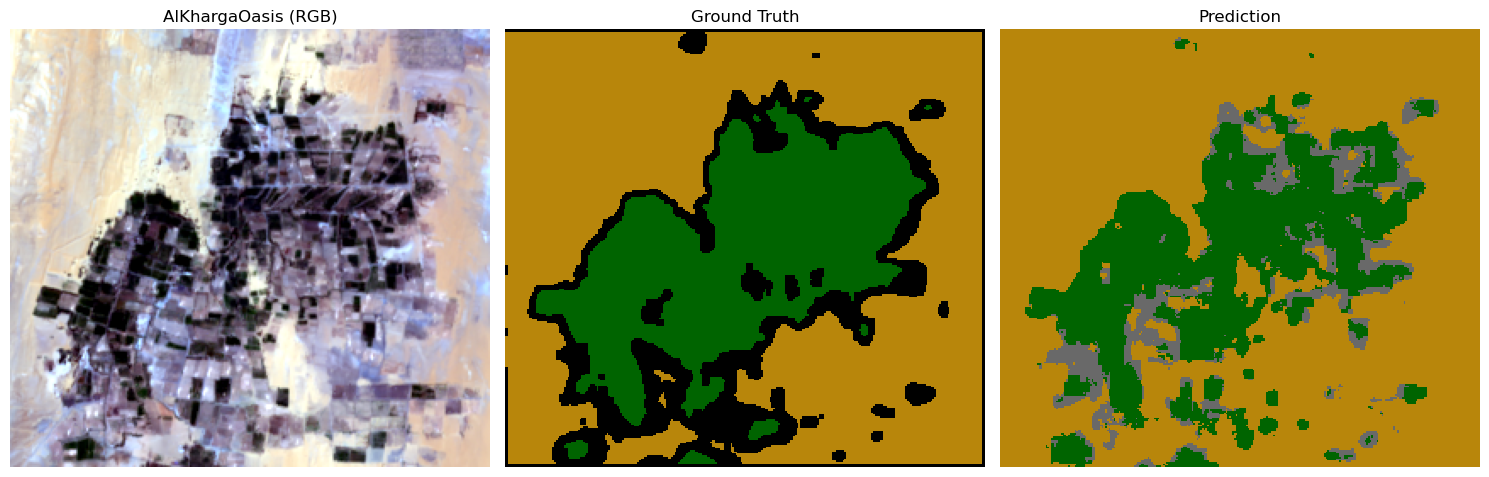

In [66]:
row = next(samples[samples["sample"].eq(TARGET_SAMPLE)].itertuples(index=False))
spectral, true = load_sample_rf(row)
pred = predict_scene_rf(model, spectral)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_preview(spectral))
axes[0].set_title(f"{row.sample} (RGB)")

axes[1].imshow(colorize(true), interpolation="nearest")
axes[1].set_title("Ground Truth")

axes[2].imshow(colorize(pred), interpolation="nearest")
axes[2].set_title("Prediction")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
plt.show()


# Deep Learning U-Net Baseline

In [67]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

MODEL_PATH = MODEL_DIR / "unet_baseline.pt"

def device_is_usable(device):
    layer = nn.Conv2d(12, 8, 3, padding=1).to(device)
    x = torch.randn(1, 12, 64, 64, device=device)
    with torch.no_grad():
        layer(x)

def choose_device():
    candidates = []
    if torch.cuda.is_available():
        candidates.append(torch.device("cuda"))
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        candidates.append(torch.device("mps"))
    candidates.append(torch.device("cpu"))
    last_error = None
    for device in candidates:
        try:
            device_is_usable(device)
            return device
        except Exception as e:
            print(f"Skipping {device}: {e}")
            last_error = e
            if device.type == "cpu" and torch.backends.mkldnn.enabled:
                print("Retrying CPU with mkldnn disabled...")
                torch.backends.mkldnn.enabled = False
                try:
                    device_is_usable(device)
                    return device
                except Exception as e2:
                    print(f"CPU retry failed: {e2}")
                    last_error = e2
    raise RuntimeError(f"No usable torch device found: {last_error}")

DEVICE = choose_device()
print("Using device:", DEVICE)

def load_sample_unet(row):
    with rio.open(row.spectral_path) as src:
        spectral = src.read().astype("float32")
    with rio.open(row.mask_path) as src:
        mask = clean_mask(src.read(1).astype("uint8"))
    return spectral, mask

def resize_scene(spectral, mask, size=IMAGE_SIZE):
    x = torch.from_numpy(spectral)
    y = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0)

    x = F.interpolate(
        x.unsqueeze(0),
        size=(size, size),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)

    y = F.interpolate(
        y.unsqueeze(0),
        size=(size, size),
        mode="nearest",
    ).squeeze(0).squeeze(0).long()

    return x, y

def prepare_scene(spectral, mask, mean, std, size=IMAGE_SIZE):
    spectral = scale_input(spectral)
    raw_x, y = resize_scene(spectral, mask, size=size)
    x = (raw_x - mean[:, None, None]) / std[:, None, None]
    return x, y, raw_x

def compute_band_stats(frame):
    total = np.zeros(12, dtype=np.float64)
    total_sq = np.zeros(12, dtype=np.float64)
    pixel_count = 0

    for row in frame.itertuples(index=False):
        spectral, _ = load_sample_unet(row)
        spectral = scale_input(spectral).reshape(12, -1)

        total += spectral.sum(axis=1)
        total_sq += (spectral ** 2).sum(axis=1)
        pixel_count += spectral.shape[1]

    mean = total / pixel_count
    std = np.sqrt(np.clip(total_sq / pixel_count - mean ** 2, 1e-8, None))

    return torch.tensor(mean, dtype=torch.float32), torch.tensor(std, dtype=torch.float32)

def compute_class_weights(frame):
    counts = np.zeros(5, dtype=np.int64)

    for row in frame.itertuples(index=False):
        _, mask = load_sample_unet(row)
        counts += np.bincount(mask.reshape(-1), minlength=5)

    active_counts = np.maximum(counts[1:], 1)
    weights = np.zeros(5, dtype=np.float32)
    weights[1:] = active_counts.sum() / active_counts
    weights[1:] /= weights[1:].mean()

    return counts, torch.tensor(weights, dtype=torch.float32)

def mean_iou_from_confusion(cm):
    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
    return intersection / np.maximum(union, 1)

def predict_scene_unet(model, spectral, mask, mean, std):
    x, y, raw_x = prepare_scene(spectral, mask, mean, std)

    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))

    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    return pred, y.numpy().astype(np.uint8), raw_x.numpy()

def evaluate_model_unet(model, frame, mean, std):
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)
    y_true, y_pred = [], []

    model.eval()

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample_unet(row)
        pred, true, _ = predict_scene_unet(model, spectral, mask, mean, std)
        valid = true > 0

        cm += confusion_matrix(true[valid], pred[valid], labels=CLASS_IDS)
        y_true.append(true[valid].reshape(-1))
        y_pred.append(pred[valid].reshape(-1))

    iou = mean_iou_from_confusion(cm)
    metrics = pd.DataFrame({
        "class_id": CLASS_IDS,
        "class_name": TARGET_NAMES,
        "IoU": iou,
        "support": cm.sum(axis=1),
    })

    report = classification_report(
        np.concatenate(y_true),
        np.concatenate(y_pred),
        labels=CLASS_IDS,
        target_names=TARGET_NAMES,
        zero_division=0,
    )

    return metrics, report


Skipping cuda: GET was unable to find an engine to execute this computation
Using device: cpu


In [68]:
outer_split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(outer_split.split(samples, groups=samples["sample"]))

train_val_df = samples.iloc[train_val_idx].reset_index(drop=True)
test_df = samples.iloc[test_idx].reset_index(drop=True)

inner_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(inner_split.split(train_val_df, groups=train_val_df["sample"]))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"train scenes: {len(train_df)}")
print(train_df["sample"].tolist())
print()
print(f"val scenes: {len(val_df)}")
print(val_df["sample"].tolist())
print()
print(f"test scenes: {len(test_df)}")
print(test_df["sample"].tolist())


train scenes: 25
['6thOfOctoberCity', 'AbuSimbel', 'AinSokhna', 'AswanHighDam', 'BahariyaOasis', 'BeniSuef', 'CairoUniv', 'DakhlaOasis', 'ElAlamein', 'ElGouna', 'Farafra', 'GreatPyramidOfGiza', 'HawaraFayoum', 'IconicTower', 'KomOmbo', 'Mallawi', 'MarsaAlam', 'MarsaMatrouh', 'Minya', 'NagHammadi', 'NewCairo', 'PhilaeAswan', 'RasMuhammadNationalPark', 'SharqElOwainat', 'Zagazig']

val scenes: 7
['EastPortSaidPort', 'Edfu', 'Hurghada', 'KarnakLuxor', 'NewAlamein', 'SuezPort', 'WadiElNatrun']

test scenes: 11
['AlKhargaOasis', 'Alexandria', 'Asyut', 'BenbanSolarPark', 'Damietta', 'LakeBurullus', 'LakeManzala', 'Qena', 'RashidRosetta', 'SaintCatherine', 'SiwaOasis']


In [69]:
band_mean, band_std = compute_band_stats(train_df)
class_counts, class_weights = compute_class_weights(train_df)

print("band mean:")
display(pd.Series(band_mean.numpy()).rename("mean"))
print()
print("class counts:")
display(pd.DataFrame({
    "class_id": list(range(5)),
    "count": class_counts,
    "weight": class_weights.numpy(),
}))


band mean:


0     0.125042
1     0.151318
2     0.205437
3     0.253467
4     0.285915
5     0.310963
6     0.324877
7     0.331513
8     0.331389
9     0.335908
10    0.359844
11    0.316631
Name: mean, dtype: float32


class counts:


,class_id,count,weight
0,0,546493,0.000000
1,1,194892,1.339943
2,2,655619,0.398317
3,3,242653,1.076204
4,4,220275,1.185537


In [70]:
class SceneDataset(Dataset):
    def __init__(self, frame, mean, std, train=False, size=IMAGE_SIZE):
        self.frame = frame.reset_index(drop=True)
        self.mean = mean.clone()
        self.std = std.clone()
        self.train = train
        self.size = size

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        spectral, mask = load_sample_unet(row)
        x, y, _ = prepare_scene(spectral, mask, self.mean, self.std, size=self.size)

        if self.train and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])
            y = torch.flip(y, dims=[1])

        if self.train and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[1])
            y = torch.flip(y, dims=[0])

        return x, y


train_ds = SceneDataset(train_df, band_mean, band_std, train=True)
val_ds = SceneDataset(val_df, band_mean, band_std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

len(train_ds), len(val_ds)


(25, 7)

In [71]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        return self.conv(torch.cat([skip, x], dim=1))


class UNet(nn.Module):
    def __init__(self, in_ch=12, out_ch=5, base=32):
        super().__init__()
        self.inc = DoubleConv(in_ch, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.bottleneck = Down(base * 8, base * 16)
        self.up1 = Up(base * 16, base * 8, base * 8)
        self.up2 = Up(base * 8, base * 4, base * 4)
        self.up3 = Up(base * 4, base * 2, base * 2)
        self.up4 = Up(base * 2, base, base)
        self.outc = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)


model = UNet().to(DEVICE)


In [72]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)

            if train_mode:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1).detach().cpu().numpy()
        true = y.detach().cpu().numpy()
        valid = true > 0

        if valid.any():
            cm += confusion_matrix(true[valid], pred[valid], labels=CLASS_IDS)

    iou = mean_iou_from_confusion(cm)
    return total_loss / len(loader.dataset), float(iou.mean())


history = []
best_val_miou = -1.0

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    train_loss, train_miou = run_epoch(train_loader, train_mode=True)
    val_loss, val_miou = run_epoch(val_loader, train_mode=False)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_miou": train_miou,
        "val_loss": val_loss,
        "val_miou": val_miou,
    })

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save({
            "model_state": model.state_dict(),
            "band_mean": band_mean,
            "band_std": band_std,
            "history": history,
        }, MODEL_PATH)

history_df = pd.DataFrame(history)
history_df


Training:   0%|          | 0/20 [00:00<?, ?it/s]

,epoch,train_loss,train_miou,val_loss,val_miou
0,1,1.314032,0.452082,1.524257,0.230001
1,2,0.961519,0.661100,1.328179,0.568403
2,3,0.802061,0.702111,1.032078,0.714661
3,4,0.753085,0.723915,0.861274,0.618544
4,5,0.725687,0.757812,0.622600,0.770705
5,6,0.749301,0.716862,0.534663,0.780196
6,7,0.711300,0.770310,0.676111,0.750212
7,8,0.709658,0.743768,0.615747,0.714065
8,9,0.656422,0.779270,0.486924,0.764883
9,10,0.683356,0.743778,0.492650,0.774996


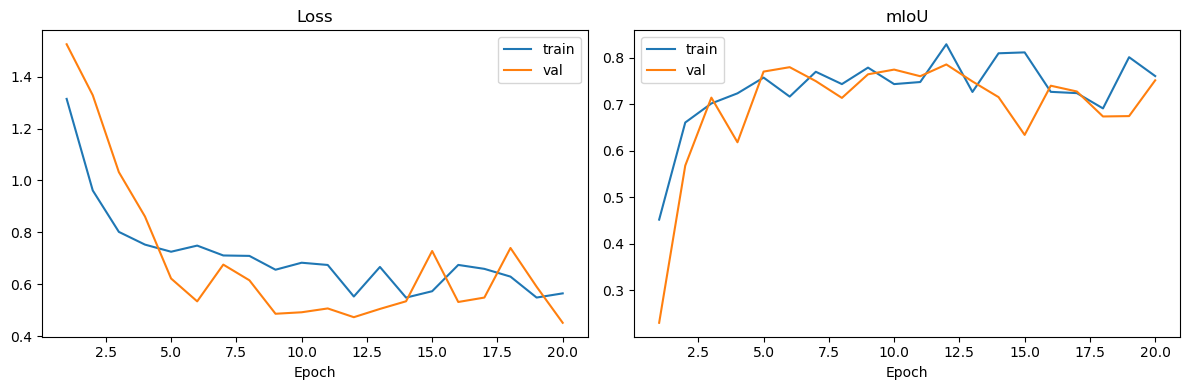

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_miou"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_miou"], label="val")
axes[1].set_title("mIoU")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [74]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])

metrics, report = evaluate_model_unet(model, test_df, band_mean, band_std)

print(f"mIoU: {metrics['IoU'].mean():.3f}")
display(metrics.sort_values("class_id"))
print()
print("Classification report")
print(report)


mIoU: 0.945


,class_id,class_name,IoU,support
0,1,Greenery,0.905889,106637
1,2,Sand,0.967467,178747
2,3,Water,0.948375,94187
3,4,Cement,0.958051,175215



Classification report
              precision    recall  f1-score   support

    Greenery       0.98      0.93      0.95    106637
        Sand       0.99      0.98      0.98    178748
       Water       0.95      1.00      0.97     94187
      Cement       0.98      0.98      0.98    175217

   micro avg       0.97      0.97      0.97    554789
   macro avg       0.97      0.97      0.97    554789
weighted avg       0.97      0.97      0.97    554789



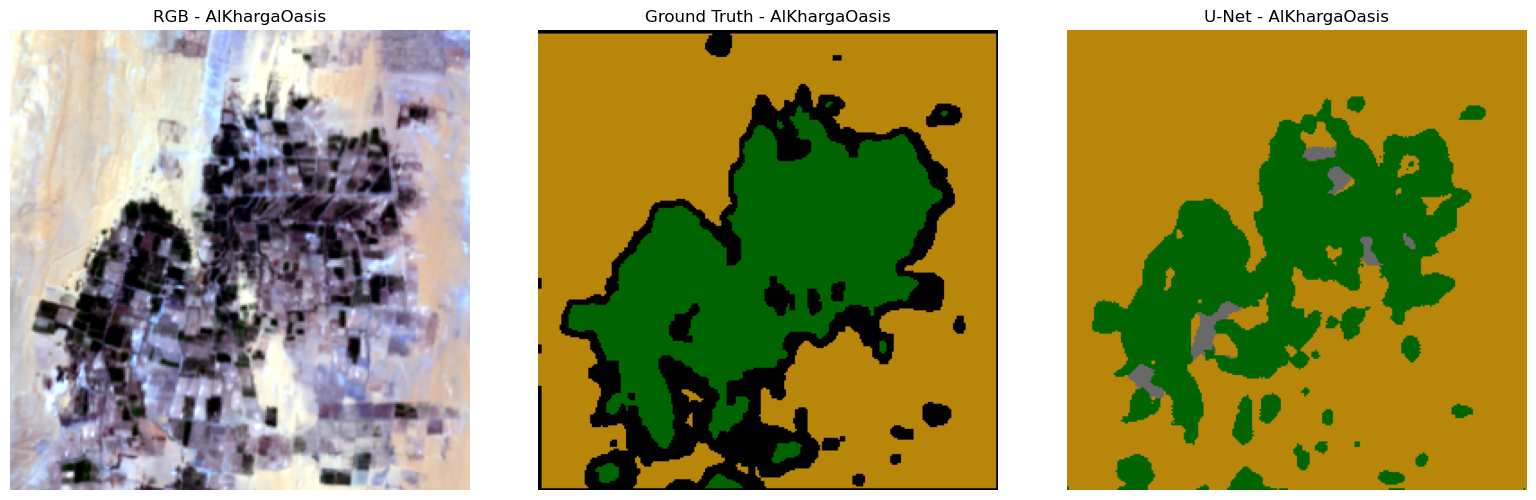

In [75]:
row = next(samples[samples["sample"].eq(TARGET_SAMPLE)].itertuples(index=False), None)
if row is None:
    raise ValueError(f"{TARGET_SAMPLE} not found in samples")

spectral, mask = load_sample_unet(row)
pred, true, raw = predict_scene_unet(model, spectral, mask, band_mean, band_std)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(rgb_preview(raw))
axes[0].set_title(f"RGB - {row.sample}")

axes[1].imshow(colorize(true))
axes[1].set_title(f"Ground Truth - {row.sample}")

axes[2].imshow(colorize(pred))
axes[2].set_title(f"U-Net - {row.sample}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [76]:
best_row = metrics.loc[metrics["IoU"].idxmax()]
worst_row = metrics.loc[metrics["IoU"].idxmin()]
best_epoch = history_df.loc[history_df["val_miou"].idxmax()]

print("Discussion")
print(
    f"U-Net used {len(train_df)} train scenes, {len(val_df)} val scenes and {len(test_df)} test scenes "
    f"for {EPOCHS} epochs at {IMAGE_SIZE}x{IMAGE_SIZE}."
)
print(
    f"Best val mIoU = {best_epoch['val_miou']:.3f} at epoch {int(best_epoch['epoch'])}, "
    f"and final test mIoU = {metrics['IoU'].mean():.3f}."
)
print(
    f"Best class: {best_row['class_name']} ({best_row['IoU']:.3f}). "
    f"Weakest class: {worst_row['class_name']} ({worst_row['IoU']:.3f})."
)
print(
    "This model captures spatial structure better, so large regions look cleaner, "
    "while class boundaries remain the main source of error."
)


Discussion
U-Net used 25 train scenes, 7 val scenes and 11 test scenes for 20 epochs at 256x256.
Best val mIoU = 0.786 at epoch 12, and final test mIoU = 0.945.
Best class: Sand (0.967). Weakest class: Greenery (0.906).
This model captures spatial structure better, so large regions look cleaner, while class boundaries remain the main source of error.
